# Lab 6.01 - Regression analysis

In [3]:
# Package imports
import numpy as np                                  # "Scientific computing"
import scipy.stats as stats                         # Statistical tests

import pandas as pd                                 # Dataframe
import matplotlib.pyplot as plt                     # Basic visualisation
from statsmodels.graphics.mosaicplot import mosaic  # Mosaic plot
import seaborn as sns                               # Advanced dataviz
from sklearn.linear_model import LinearRegression

## Exercise 1: Relation between heart weight and body weight in Cats

### Part 1

Perform a linear regression analysis on the variables body weight (`Bwt`, dependent variable) and heart weight (`Hwt`, independent variabele).


1. Import the dataset `Cats.csv`.


In [5]:
cats = pd.read_csv('https://raw.githubusercontent.com/HoGentTIN/dsai-labs/main/data/Cats.csv', index_col=0)
# Show the first few records of the Data Frame
cats.head()

,Sex,Hwt,Bwt
ID,,,
1,F,2.0,7.0
2,F,2.0,7.4
3,F,2.0,9.5
4,F,2.1,7.2
5,F,2.1,7.3


2. Draw a scatter plot of both variables.


<Axes: xlabel='Bwt', ylabel='Hwt'>

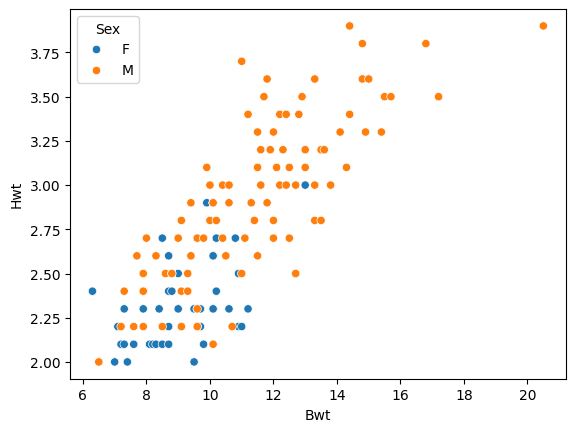

In [6]:
sns.scatterplot(data=cats, x="Bwt", y="Hwt", hue="Sex")

3. Calculate and draw the regression line.


In [20]:
stats.linregress(cats["Hwt"], cats["Bwt"])

LinregressResult(slope=np.float64(4.031757486783178), intercept=np.float64(-0.3510783771969628), rvalue=np.float64(0.8041347873155132), pvalue=np.float64(6.952419225113617e-34), stderr=np.float64(0.25011199659585515), intercept_stderr=np.float64(0.6918635122787294))

<Axes: xlabel='Hwt', ylabel='Bwt'>

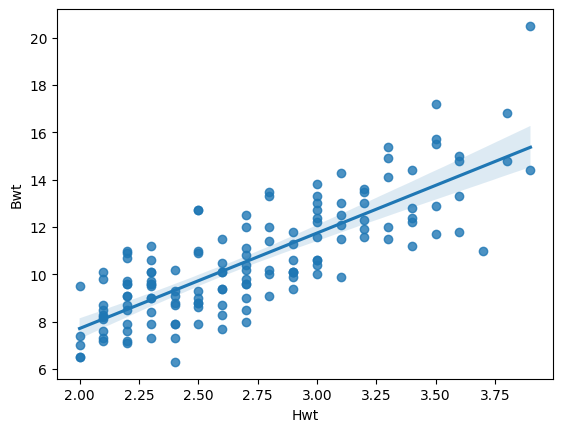

In [18]:
sns.regplot(data=cats, x="Hwt", y="Bwt")

4. Calculate the correlation coefficient and the coefficient of determination.

In [13]:
print(np.corrcoef(cats["Bwt"], cats["Hwt"])[0, 1])
print(np.corrcoef(cats["Bwt"], cats["Hwt"])[0, 1]**2)

0.8041347873155131
0.6466327561709655


5. Interpret the results from the previous steps.

### Part 2

1. Perform a linear regression analysis on the variables body weight (`Bwt`) and heart weight (`Hwt`), but this time **subdivided by gender** (`Sex`). Use the same dataset (`Cats.csv`).


In [8]:
cats = pd.read_csv('https://raw.githubusercontent.com/HoGentTIN/dsai-labs/main/data/Cats.csv', index_col=0)
# Show the first few records of the Data Frame
cats.head()

,Sex,Hwt,Bwt
ID,,,
1,F,2.0,7.0
2,F,2.0,7.4
3,F,2.0,9.5
4,F,2.1,7.2
5,F,2.1,7.3


2. Draw a scatter plot of both variables for each gender.


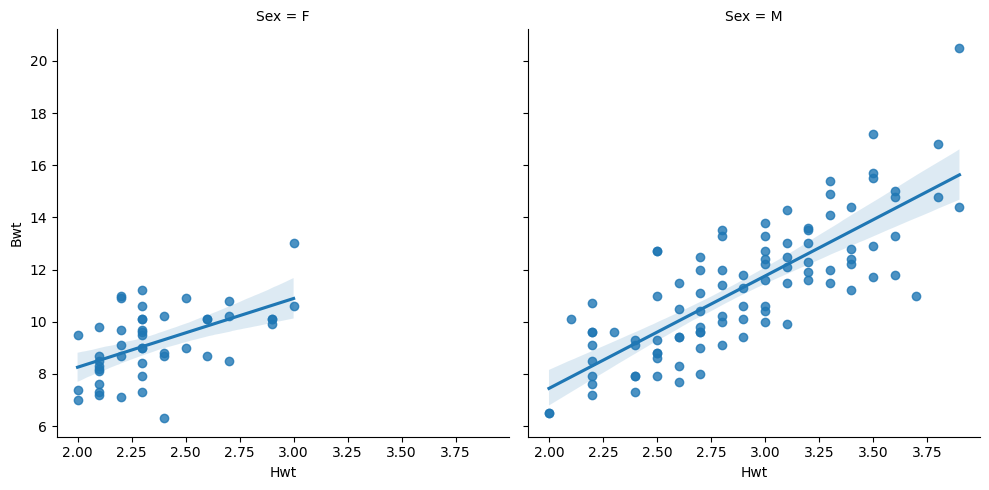

In [9]:
sns.lmplot(data=cats, x='Hwt', y='Bwt', col='Sex')

In [13]:
cats_m = cats[cats['Sex'] == 'M']
cats_f = cats[cats['Sex'] == 'F']

3. Calculate and draw the regression line.


In [14]:
stats.linregress(cats_m["Bwt"], cats_m["Hwt"])

LinregressResult(slope=np.float64(0.14592708121546175), intercept=np.float64(1.247864736177112), rvalue=np.float64(0.7930443171812303), pvalue=np.float64(3.628961790992493e-22), stderr=np.float64(0.011500343859474495), intercept_stderr=np.float64(0.1334077703793235))

In [15]:
stats.linregress(cats_f["Hwt"], cats_f["Bwt"])

LinregressResult(slope=np.float64(2.6364140480591507), intercept=np.float64(2.9813123844731946), rvalue=np.float64(0.5320496665060398), pvalue=np.float64(0.00011861701596435437), stderr=np.float64(0.6254484027655178), intercept_stderr=np.float64(1.4854977376315788))

4. Calculate the correlation coefficient and the coefficient of determination.


In [16]:
cor = np.corrcoef(cats_m["Hwt"], cats_m["Bwt"])[0][1]
print(cor)
cor2 = cor ** 2
print(cor2)

0.7930443171812304
0.628919289013444


In [17]:
cor = np.corrcoef(cats_f["Hwt"], cats_f["Bwt"])[0][1]
print(cor)
cor2 = cor ** 2
print(cor2)



0.5320496665060397
0.28307684762918806


5. Interpret the results from the previous steps.

### Answers

| Selection |  $\beta_0$ | $\beta_1$ |       $R$ |     $R^2$ |
| :-------- | ---------: | --------: | --------: | --------: |
| All       | -0.3510784 | 4.0317575 | 0.8041348 | 0.6466328 |
| Male      | -1.1768253 | 4.3098189 | 0.7930443 | 0.6289193 |
| Female    |  2.9813124 |  2.636414 | 0.5320497 | 0.2830768 |
